# Machine learning for network traffic analysis in cybersecurity


### Πτυχιακή Εργασία

#### Φοιτητής: Γαραζανάκης Κωνσταντίνος  

---

Το παρόν Jupyter Notebook αποτελεί το πρακτικό παραδοτέο (ML Pipeline) της πτυχιακής εργασίας. Υλοποιεί μια end-to-end αρχιτεκτονική εντοπισμού κυβερνοαπειλών (DDoS, Botnets, Web Attacks), εκπαιδεύοντας αλγορίθμους Μηχανικής Μάθησης πάνω στο σύνολο δεδομένων του CIC-IDS2017.  

---

### Τεχνικές Προδιαγραφές & Βελτιστοποιήσεις Κώδικα

Για τη διασφάλιση reproducibility και την αποτροπή εξάντλησης πόρων του συστήματος (Errors για Out-Of-Memory/CPU Locking) κατά την επεξεργασία εκατομμυρίων δικτυακών ροών, ο κώδικας έχει βελτιστοποιηθεί στα εξής επίπεδα:

- pathlib για τη δυναμική φόρτωση των CSV αρχείων, επιτρέποντας την εκτέλεση του κώδικα σε περιβάλλοντα Linux, Windows και macOS χωρίς αλλαγές στα paths.  

- Memory Downcasting & Garbage Collection για την άμεση αποδέσμευση της μνήμης RAM από ενδιάμεσα DataFrames.  

- Πρόληψη CPU Bottleneck: Στον αλγόριθμο Random Forest, η χρήση επεξεργαστικών νημάτων περιορίστηκε συνειδητά (n_jobs=2) κατά την εκπαίδευση σε ογκώδη δεδομένα, διασφαλίζοντας τη σταθερότητα του λειτουργικού συστήματος.  

- Για τις συγκρίσεις βαρέων αλγορίθμων (π.χ. Deep Learning / MLP), η εκπαίδευση εκτελείται σε αυστηρά χρονολογικά slices (π.χ. 300.000 εγγραφών) που διατηρούν την ταξική κατανομή των επιθέσεων, αποφεύγοντας τα memory crashes. Η επιλογή για την εκπαίδευση υπάρχει ακόμα στον κώδικα με την αλλαγή sub -> shuf  ->> πχ X_test_sub -> X_test_shuf

- Προσαρμογή Διαστάσεων και δημιουργία προσαρμοσμένων συναρτήσεων (extract_1d_shap) για την επίλυση dimension mismatches
 κατά την παραγωγή των τοπικών επεξηγήσεων του αλγορίθμου SHAP.  
---
### Dataset Setup
Οι ερευνητές που επιχειρούν να αναπαραγάγουν αυτόν τον κώδικα καλό είναι να χρησιμοποιήσουν απομονωμένα virtual environments.

Ένα εικονικό περιβάλλον πρέπει να δημιουργηθεί στον root κατάλογο του έργου χρησιμοποιώντας την εντολή: 
>python3 -m venv .venv.

Το περιβάλλον πρέπει να ενεργοποιηθεί πριν από την εγκατάσταση των εξαρτήσεων: 

>source .venv/bin/activate.

Η για Windows 

> .\.venv\Scripts\activate 

Αν δεν τρέχει επειδη λεει οτι running scripts is disabled on this system δοκίμασε

> Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope CurrentUser 

και μέτα την έντολη .\.venv\Scripts\activate 

Εντός του VS Code, ο kernel του Jupyter πρέπει να αντιστοιχιστεί ρητά στη διαδρομή αυτού του εικονικού περιβάλλοντος ***(./.venv/bin/python)*** και όχι στην καθολική Python του συστήματος.
Η εκτέλεση ενσωματωμένων εγκαταστάσεων πακέτων (π.χ. %pip install) εντός των κελιών του Jupyter Notebook αποτυγχάνει εάν λείπει το πακέτο ipykernel, προκαλώντας ένα επαναλαμβανόμενο σφάλμα στο VS Code σχετικά με εξαρτήσεις που λείπουν.

Πρέπει να εγκατασταθεί είτε μέσω του διαχειριστή πακέτων του συστήματος ***(sudo apt install python3-ipykernel)*** είτε να εισαχθεί απευθείας στο ενεργό εικονικό περιβάλλον ***(pip install ipykernel)*** μέσω του τερματικού πριν εκτελεστεί κώδικας του notebook. **Μετά την εγκατάσταση, απαιτείται επανεκκίνηση του kernel.**

Extra Help: Σε περίπτωση crash λόγω μνήμης, οι "ορφανές" background processes πρέπει να τερματιστούν χειροκίνητα χρησιμοποιώντας την εντολή τερματικού pkill -f python πριν από την επαναφόρτωση του παραθύρου του VS Code.




In [1]:
# Install Required Packages

%pip install scikit-learn
%pip install shap
%pip install numpy
%pip install pandas
%pip install matplotlib
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder # for encoding and value scaling of data
import time
import seaborn as sns
import gc

### Importing files of CIC-IDS2017 and fixing the dataset

In [3]:
# Module 2.5 Preprocessing Pipeline
# ===============================================


from pathlib import Path # We use this to ensure capability of execution across different OS users


# Get the directory where this notebook is saved
BASE_DIR = Path(__file__).parent if '__file__' in locals() else Path.cwd()

DATA_DIR = BASE_DIR / "TrafficLabelling" # works on Windows & Linux tested method, all ok

# !!! make sure to create a folder named TrafficLabelling with all the data of CIC-IDS2017 inside


#Loading the files from CICIDS 2017 Dataset zip file
print("Loading files from dataset")

csv_files = [
    "Monday-WorkingHours.pcap_ISCX.csv",
    "Tuesday-WorkingHours.pcap_ISCX.csv",
    "Wednesday-workingHours.pcap_ISCX.csv",
    "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
    "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
    "Friday-WorkingHours-Morning.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"
]

data_list = []

for file in csv_files:
    print(f"  -> Loading {file}...")
    temp_df = pd.read_csv(DATA_DIR / file, encoding='latin1', low_memory=True)
    data_list.append(temp_df)

print("Combining Datasets... ")
data = pd.concat(data_list, ignore_index=True)

del data_list
gc.collect()

# data1 = pd.read_csv(DATA_DIR / "Monday-WorkingHours.pcap_ISCX.csv", encoding='latin1', low_memory=True)
# data2 = pd.read_csv(DATA_DIR / "Tuesday-WorkingHours.pcap_ISCX.csv", encoding='latin1', low_memory=True)
# data3 = pd.read_csv(DATA_DIR / "Wednesday-workingHours.pcap_ISCX.csv", encoding='latin1', low_memory=True)
# data4 = pd.read_csv(DATA_DIR / "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv", encoding='latin1', low_memory=True)
# data5 = pd.read_csv(DATA_DIR / "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv", encoding='latin1', low_memory=True)
# data6 = pd.read_csv(DATA_DIR / "Friday-WorkingHours-Morning.pcap_ISCX.csv", encoding='latin1', low_memory=True)
# data7 = pd.read_csv(DATA_DIR / "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv", encoding='latin1', low_memory=True)
# data8 = pd.read_csv(DATA_DIR / "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv", encoding='latin1', low_memory=True)


# data_list = [data1, data2, data3, data4, data5, data6, data7, data8]

# data = pd.concat(data_list, ignore_index=True)
print(f"Dimensions after Union:  {data.shape}")

# for d in data_list: 
#     del d   # Clear memory


data.columns = data.columns.str.strip() #Removing Whitespaces from left or right of the names

print("Removing Duplicates...")
data.drop_duplicates(inplace=True)
print(f"New Dimensions without duplicates:  {data.shape}")

print("Cleanup of weird values (Infinity και NaN)...")

data.replace([np.inf, -np.inf], np.nan, inplace=True) # we make the infinitys NaN
data.dropna(inplace=True) # then we drop them from the dataset
print(f"D after cleanup: {data.shape}")

leakage_cols = ['Source IP', 'Destination IP', 'Source Port', 'Timestamp']
cols_to_drop = [col for col in leakage_cols if col in data.columns]
if cols_to_drop:
    data.drop(columns=cols_to_drop, inplace=True)
    print(f"Removed Leakage Columns {cols_to_drop}")

print("\nLoading and Cleanup of dataset Complete!")
print(data['Label'].value_counts())

Loading files from dataset
  -> Loading Monday-WorkingHours.pcap_ISCX.csv...
  -> Loading Tuesday-WorkingHours.pcap_ISCX.csv...
  -> Loading Wednesday-workingHours.pcap_ISCX.csv...
  -> Loading Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv...


/tmp/ipykernel_3872/523914089.py:34: DtypeWarning: Columns (0: Flow ID, 1:  Source IP, 2:  Destination IP, 3:  Timestamp, 4:  Label) have mixed types. Specify dtype option on import or set low_memory=False.
  temp_df = pd.read_csv(DATA_DIR / file, encoding='latin1', low_memory=True)


  -> Loading Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv...
  -> Loading Friday-WorkingHours-Morning.pcap_ISCX.csv...
  -> Loading Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv...
  -> Loading Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv...
Combining Datasets... 
Dimensions after Union:  (3119345, 85)
Removing Duplicates...
New Dimensions without duplicates:  (2830541, 85)
Cleanup of weird values (Infinity και NaN)...
D after cleanup: (2827677, 85)
Removed Leakage Columns ['Source IP', 'Destination IP', 'Source Port', 'Timestamp']

Loading and Cleanup of dataset Complete!
Label
BENIGN                        2271122
DoS Hulk                       230123
PortScan                       158804
DDoS                           128025
DoS GoldenEye                   10293
FTP-Patator                      7935
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1956
Web Atta

### Normalising, Encoding, and Time-aware Splitting the Data for use in training

In [4]:
# Module 2.5 Preprocessing Pipeline
# ===============================================

print("Final Preprocessing Stage")

# First We seperate Characteristics X and Labels Y
excludeFlowID = ['Label']
if 'Flow ID ' in data.columns:
    excludeFlowID.append ('Flow ID') #we explicitly exclude FlowId since we forgot to do it earlier (with sourceIp e.t.c)
                                     # and it raised a string error doing calculations with float numbers

X = data.drop(columns=excludeFlowID)
X_numbers = X.select_dtypes(include= ['int64', 'Float64', 'int32', 'Float32'])
print(f"  We have {X_numbers.shape[1]} X Characteristics")

y = data['Label']

# feature scaling
print("Applying StandardScaler in features (X)... ")
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_numbers), columns=X_numbers.columns) # fit_transform to all X

#Label Encoding
print("Performing Label Encoding (Y)... ")
encoder = LabelEncoder()
y_encoded = pd.Series(encoder.fit_transform(y), name='Label')

# Print for ease (Class -> Number)
label_mapping = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))
print("\nClasses: ")
for label, code in label_mapping.items():
    print(f"  {label}: {code}")

# Time Aware splitting

# Based on theory, we split the first 80% as past (training) and the final 20% as future (testing)
# with shuffle=False of data.

print("\nTime Aware splitting here:")
split_index = int(len(X_scaled) * 0.8)

X_train = X_scaled.iloc[:split_index]
X_test = X_scaled.iloc[split_index:]
y_train = y_encoded.iloc[:split_index]
y_test = y_encoded.iloc[split_index:]

print(f"  Training set: {X_train.shape[0]} regs (80%)")
print(f"  Testing set: {X_test.shape[0]} regs (20%)")

print("\nTraffic Dataset Preprocessing Pipeline Done!")

Final Preprocessing Stage
  We have 79 X Characteristics
Applying StandardScaler in features (X)... 
Performing Label Encoding (Y)... 

Classes: 
  BENIGN: 0
  Bot: 1
  DDoS: 2
  DoS GoldenEye: 3
  DoS Hulk: 4
  DoS Slowhttptest: 5
  DoS slowloris: 6
  FTP-Patator: 7
  Heartbleed: 8
  Infiltration: 9
  PortScan: 10
  SSH-Patator: 11
  Web Attack  Brute Force: 12
  Web Attack  Sql Injection: 13
  Web Attack  XSS: 14

Time Aware splitting here:
  Training set: 2262141 regs (80%)
  Testing set: 565536 regs (20%)

Traffic Dataset Preprocessing Pipeline Done!


### Which Traffic features seem most useful and why?

Starting Feature Importance Evaluation on Full Train Set... (This may take a few minutes)

--- Top 15 Features ---
                        Feature  Importance
43       Packet Length Variance    0.080133
0              Destination Port    0.073195
14        Bwd Packet Length Std    0.067720
42            Packet Length Std    0.054410
11        Bwd Packet Length Max    0.052277
13       Bwd Packet Length Mean    0.048504
67       Init_Win_bytes_forward    0.045894
55         Avg Bwd Segment Size    0.035652
23                  Fwd IAT Std    0.035087
6   Total Length of Bwd Packets    0.033218
18                 Flow IAT Std    0.026826
66            Subflow Bwd Bytes    0.023969
19                 Flow IAT Max    0.022594
41           Packet Length Mean    0.020787
40            Max Packet Length    0.019381


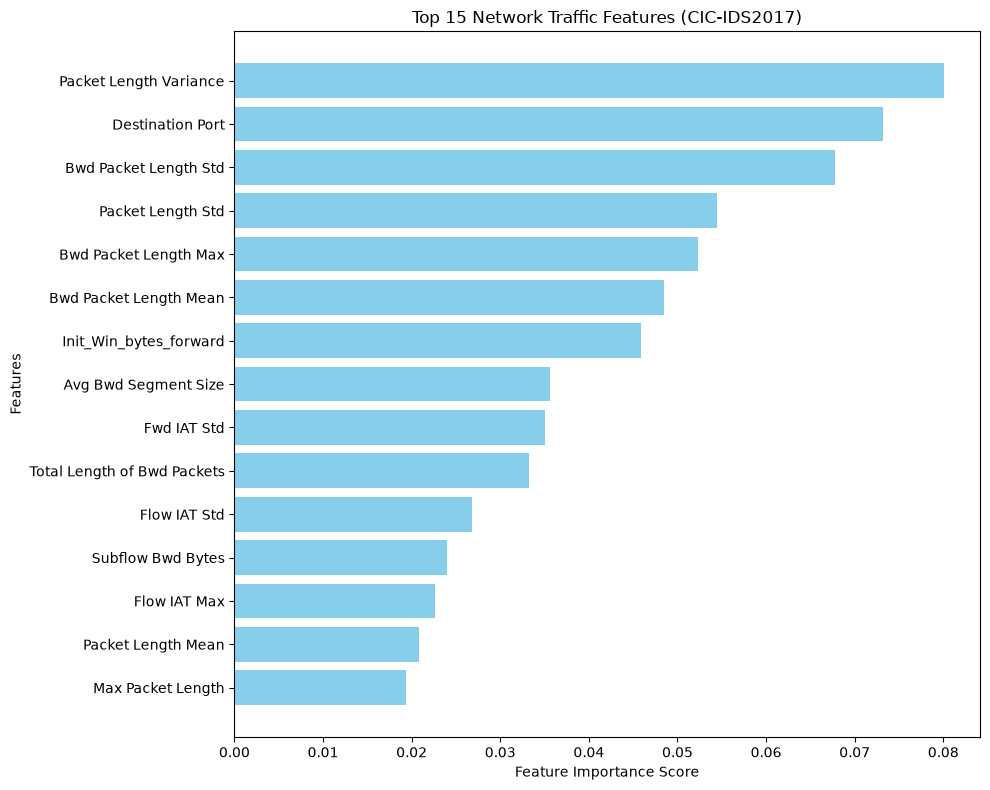


New Train/Test sets created with 15 columns!


In [5]:

# Module 3.2 Feature Selection with Random Forest
# ===============================================
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

print("Starting Feature Importance Evaluation on Full Train Set... (This may take a few minutes)")

# Train a Random Forest to evaluate feature importance
# Using 50 trees and all CPU cores (n_jobs=-1) for speed
rf_selector = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf_selector.fit(X_train, y_train)

# Extract and sort feature importances
importances = rf_selector.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Keep the Top 15 most important features
top_15_features = feature_importance_df.head(15)

print("\n--- Top 15 Features ---")
print(top_15_features)

# Plotting the Top 15 features
plt.figure(figsize=(10, 8))
plt.barh(top_15_features['Feature'][::-1], top_15_features['Importance'][::-1], color='skyblue')
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.title('Top 15 Network Traffic Features (CIC-IDS2017)')
plt.tight_layout()
plt.show()

# Create the final, dimensionality-reduced DataFrames
top_feature_names = top_15_features['Feature'].tolist()

X_train_selected = X_train[top_feature_names]
X_test_selected = X_test[top_feature_names]

print(f"\nNew Train/Test sets created with {X_train_selected.shape[1]} columns!")

Executing PCA for data Visualisation


/tmp/ipykernel_3872/2057153422.py:40: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/sifous/Desktop/Ptyxiaki/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


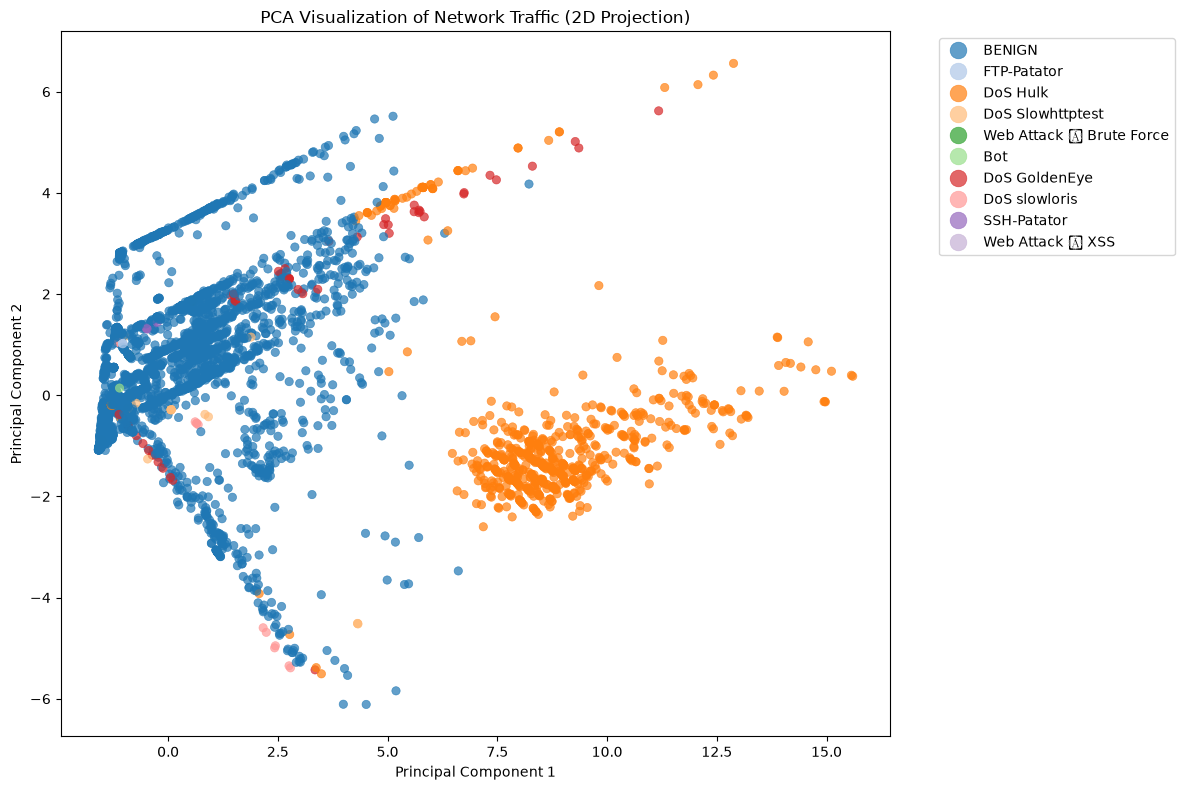

In [6]:
# Module 3.4 && 3.5 Dimensionality Reduction Visualization (PCA)
# ==========================================

from sklearn.decomposition import PCA

print("Executing PCA for data Visualisation")


sample_indices = X_train_selected.sample(n=10000, random_state=42).index # well use a random sample of 10,000 lines because on all 2M lines, pc crached
X_vis = X_train_selected.loc[sample_indices]
y_vis = y_train.loc[sample_indices]


pca = PCA(n_components=2, random_state=42) # PCA to drop 15 dimentions to 2 to be plottable on x, y
X_pca = pca.fit_transform(X_vis)


pca_df = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'])


reverse_label_mapping = {v: k for k, v in label_mapping.items()} 
pca_df['Label'] = y_vis.map(reverse_label_mapping).values # replacing with actual attack names here instead of 0,1,...

# Seaborn Visualisation
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='Principal Component 1', 
    y='Principal Component 2',
    hue='Label',
    palette='tab20', # paleta me polla xrwmata gia tis diaforetikes klaseis
    data=pca_df,
    alpha=0.7,
    edgecolor=None
)

plt.title('PCA Visualization of Network Traffic (2D Projection)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=2)
plt.tight_layout()
plt.show()

In [7]:
# Module 4.1.5: Supervised Learning Baselines // Dataset shift and concept drift && Time-aware splitting vs random splitting
# ==========================================
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print("Training Baseline Models in the 15 Features we found\n")

# Orizoume ta montela p tha xrisimopoiisoume
# Xrisimopoioume max_depth sto Tree kai sto Forest 
# gia na kratisoume to train grigoro kai na apofygoume akraio overfitting.

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Random Forest (Light)": RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
}

results = []

# Training and Evaluation of different models
for name, model in models.items():
    print(f"-> Training model: {name}...")
    start_time = time.time()
    
    
    model.fit(X_train_selected, y_train) # Training on train set (past)
    
    y_pred = model.predict(X_test_selected)  #Prediction on test set (future)
    
    end_time = time.time()
    
    # Metrics (weighted due to class imbalance)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    # save
    results.append({
        "Model": name,
        "Accuracy (%)": round(acc * 100, 3),
        "Precision (W)": round(prec, 4),
        "Recall (W)": round(rec, 4),
        "F1-Score (W)": round(f1, 4),
        "Training Time (s)": round(end_time - start_time, 2)
    })

# Benchmark Table
results_df = pd.DataFrame(results)
print("\n--- Benchmark table of Models ---")
print(results_df.to_string(index=False))

Training Baseline Models in the 15 Features we found

-> Training model: Decision Tree...
-> Training model: Logistic Regression...
-> Training model: Random Forest (Light)...
-> Training model: K-Nearest Neighbors...

--- Benchmark table of Models ---
                Model  Accuracy (%)  Precision (W)  Recall (W)  F1-Score (W)  Training Time (s)
        Decision Tree        48.414         0.2581      0.4841        0.3366              23.86
  Logistic Regression        48.824         0.2817      0.4882        0.3573             154.53
Random Forest (Light)        49.131         0.2830      0.4913        0.3591              38.33
  K-Nearest Neighbors        49.092         0.2717      0.4909        0.3497              17.34


In [8]:
# Module 4.1.5: Supervised Learning Baselines (Shuffled) 
# ==========================================

from sklearn.model_selection import train_test_split




print("Remaking train/test sets with shuffle for baseline extraction\n")

X_train_shuf, X_test_shuf, y_train_shuf, y_test_shuf = train_test_split( X_scaled[top_feature_names], y_encoded, test_size=0.20, random_state=42)

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5, n_jobs=-1)

}

results = []

for name, model in models.items():
    print(f"-> Training Model {name}...")
    start_time = time.time()
    
    model.fit(X_train_shuf, y_train_shuf)
    y_pred = model.predict(X_test_shuf)
    
    end_time = time.time()
    
    acc = accuracy_score(y_test_shuf, y_pred)
    prec = precision_score(y_test_shuf, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test_shuf, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test_shuf, y_pred, average='weighted', zero_division=0)
    
    results.append({
        "Model": name,
        "Accuracy (%)": round(acc * 100, 3),
        "Precision (W)": round(prec, 4),
        "Recall (W)": round(rec, 4),
        "F1-Score (W)": round(f1, 4),
        "Training Time (s)": round(end_time - start_time, 2)
    })

results_df = pd.DataFrame(results)
print("\n--- Benchmark Table of Models (Shuffled Baseline) ---")
print(results_df.to_string(index=False))

Remaking train/test sets with shuffle for baseline extraction

-> Training Model Decision Tree...
-> Training Model Logistic Regression...
-> Training Model Random Forest...
-> Training Model K-Nearest Neighbors...

--- Benchmark Table of Models (Shuffled Baseline) ---
              Model  Accuracy (%)  Precision (W)  Recall (W)  F1-Score (W)  Training Time (s)
      Decision Tree        99.843         0.9984      0.9984        0.9984              23.38
Logistic Regression        89.624         0.8855      0.8962        0.8839             451.37
      Random Forest        99.718         0.9972      0.9972        0.9972              43.93
K-Nearest Neighbors        99.808         0.9981      0.9981        0.9981              19.37


In [10]:
# Module 4.2.2 Unsupervised Learning (Anomaly Detection)
# ==========================================

from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix

print("Unsupervised learning with Isolation Forrest\n")

# Data prep: We train based solely on Benign Traffic Movement
benign_indices = y_train_shuf[y_train_shuf == 0].index
X_train_benign = X_train_shuf.loc[benign_indices]

print(f"-> Training exclusively on {len(X_train_benign)} regs of Benign Traffic")

# Training
# contamination: Estimated percentage of noise (0.05% as a logic)
iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42, n_jobs=-1)

start_time = time.time()
iso_forest.fit(X_train_benign)

# Test Set
# Returns: 1 for normal (Inlier), -1 for Anomaly (Outlier)
print("-> Predict on unknown data (Test Set) with attacks...")
y_pred_iso = iso_forest.predict(X_test_shuf)
end_time = time.time()


# Turning real y_test in Isolation Forest form:
# - Normal Traffic (BENIGN, 0) -> 1
# - Any Attack (>0) -> -1
y_test_anomaly = y_test_shuf.apply(lambda x: 1 if x == 0 else -1)

# Results
print(f"Training Time & Prediction: {round(end_time - start_time, 2)} seconds\n")
print("--- Report (Anomaly Detection) ---")
# We focus on how well it found -1
print(classification_report(y_test_anomaly, y_pred_iso, target_names=['Anomaly/Attack (-1)', 'Normal/Benign (1)']))

Unsupervised learning with Isolation Forrest

-> Training exclusively on 1817110 regs of Benign Traffic
-> Predict on unknown data (Test Set) with attacks...
Training Time & Prediction: 5.94 seconds

--- Report (Anomaly Detection) ---
                     precision    recall  f1-score   support

Anomaly/Attack (-1)       0.68      0.44      0.54    111524
  Normal/Benign (1)       0.87      0.95      0.91    454012

           accuracy                           0.85    565536
          macro avg       0.78      0.70      0.72    565536
       weighted avg       0.84      0.85      0.84    565536



Extracting slice to prevent RAM overflow...
Aggregating flows into time-windows to capture attack rhythm...
Training models (Per-flow vs Window-based)...

--- Model Comparison ---
Per-flow Classification F1-Score:     0.9979
Window-based Classification F1-Score: 0.9924
Locating a volumetric DDoS attack for visualization...


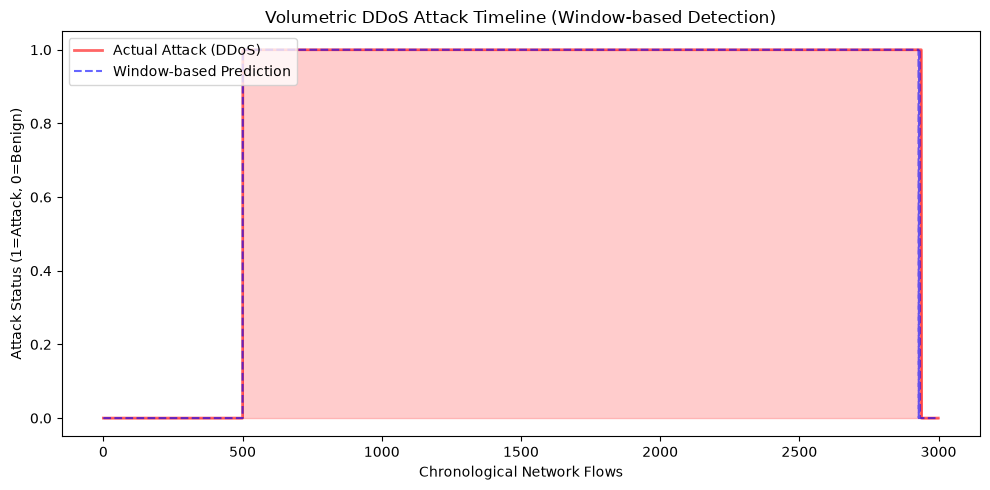

In [ ]:
# Module 4.3.3: Botnet and DDoS Traffic Analysis (Memory Optimized)
# ==========================================

from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

# Filter dataset for specific attacks (BENIGN, Bot, DDoS)
valid_labels = [label_mapping['BENIGN'], label_mapping['DDoS'], label_mapping['Bot']]
mask = y_encoded.isin(valid_labels)

#this is an "after the fact" fix because it kept eating up my RAM, so since I have all my results I did this so its executable
print("Extracting slice to prevent RAM overflow...")


# We take the last 400000 lines with DDoS for Ram preservation
# downcasting to float32 to save 50% memory
X_focus = X_scaled.loc[mask, top_feature_names].iloc[-400000:].copy().astype('float32')
y_focus = y_encoded[mask].iloc[-400000:].copy()

# Convert to binary classification in 8-bit int (0: BENIGN, 1: Attack)
y_binary = (y_focus != label_mapping['BENIGN']).astype(np.int8)

# Create time-window aggregation (rolling mean over 3000 consecutive flows)
print("Aggregating flows into time-windows to capture attack rhythm...")
window_size = 3000
X_windowed = X_focus.rolling(window=window_size, min_periods=1).mean().astype('float32')

print("Training models (Per-flow vs Window-based)...")
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X_focus, y_binary, test_size=0.2, random_state=42)

# clean memory
del X_focus
gc.collect()

X_train_win, X_test_win, y_train_win, y_test_win = train_test_split(X_windowed, y_binary, test_size=0.2, random_state=42)

# Train lightweight classifiers (n_jobs=2 to prevent CPU locking)
clf_raw = RandomForestClassifier(n_estimators=30, max_depth=10, random_state=42, n_jobs=2)
clf_win = RandomForestClassifier(n_estimators=30, max_depth=10, random_state=42, n_jobs=2)

clf_raw.fit(X_train_raw, y_train_raw)
clf_win.fit(X_train_win, y_train_win)

# Evaluate and compare
preds_raw = clf_raw.predict(X_test_raw)
preds_win = clf_win.predict(X_test_win)

print("\n--- Model Comparison ---")
print(f"Per-flow Classification F1-Score:     {f1_score(y_test_raw, preds_raw):.4f}")
print(f"Window-based Classification F1-Score: {f1_score(y_test_win, preds_win):.4f}")

# Visualize attack periods on a timeline
print("Locating a volumetric DDoS attack for visualization...")
y_focus_vals = y_focus.values

# Looking for the point where benign turns to DDoS
ddos_transitions = np.where((y_focus_vals[:-1] == label_mapping['BENIGN']) & 
                            (y_focus_vals[1:] == label_mapping['DDoS']))[0]

# First big DDoS transition in our slice
attack_start_idx = ddos_transitions[0] 

vis_start = max(0, attack_start_idx - 500)
vis_end = min(len(y_binary), vis_start + 3000)

timeline_y = y_binary.iloc[vis_start:vis_end].values
timeline_X_win = X_windowed.iloc[vis_start:vis_end]
timeline_preds = clf_win.predict(timeline_X_win)

plt.figure(figsize=(10, 5))
plt.plot(timeline_y, label="Actual Attack (DDoS)", color='red', alpha=0.6, linewidth=2)
plt.plot(timeline_preds, label="Window-based Prediction", color='blue', alpha=0.6, linestyle='dashed')
plt.fill_between(range(len(timeline_y)), 0, timeline_y, color='red', alpha=0.2)
plt.title('Volumetric DDoS Attack Timeline (Window-based Detection)')
plt.xlabel('Chronological Network Flows')
plt.ylabel('Attack Status (1=Attack, 0=Benign)')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
# Module 4.4: Deep Learning for Traffic Analysis
# ==========================================

import time
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


print("Subsampling data to prevent Memory Crash...")

# deigma 300.000 kai metatropi σε float32 gia eksoikonomisi mnimis opote to ra f1 scores isos diaforopoiountai LIGO apo afta tou report, me to idio omos apotelesma
SAMPLE_SIZE = 300000
X_train_sub = X_train_shuf.iloc[:SAMPLE_SIZE].astype('float32')
y_train_sub = y_train_shuf.iloc[:SAMPLE_SIZE]
X_test_sub = X_test_shuf.iloc[:int(SAMPLE_SIZE*0.2)].astype('float32')
y_test_sub = y_test_shuf.iloc[:int(SAMPLE_SIZE*0.2)]

# An theloume na paroume olo to dataset arkei apla na antitatastisoume
# X_train_sub - > X_train_shuf
# y_train_sub -> y_train_shuf
# X_test_sub -> X_test_shuf
# y_test_sub -> y_test_shuf

# Setup the Multi-Layer Perceptron (MLP)
mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    batch_size=1024,
    max_iter=300,
    early_stopping=True,
    random_state=42
)

# Train and Evaluate MLP
print("-> Training Neural Network (MLP). This will take some time...")
start_time_mlp = time.time()
mlp_model.fit(X_train_sub, y_train_sub)
preds_mlp = mlp_model.predict(X_test_sub)
time_mlp = time.time() - start_time_mlp

acc_mlp = accuracy_score(y_test_sub, preds_mlp)
prec_mlp = precision_score(y_test_sub, preds_mlp, average='weighted', zero_division=0)
rec_mlp = recall_score(y_test_sub, preds_mlp, average='weighted', zero_division=0)
f1_mlp = f1_score(y_test_sub, preds_mlp, average='weighted', zero_division=0)

# For direct comparison, we retrieve the Random Forest performance
print("-> Training Random Forest Baseline...")
rf_model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
start_time_rf = time.time()
rf_model.fit(X_train_sub, y_train_sub)
preds_rf = rf_model.predict(X_test_sub)
time_rf = time.time() - start_time_rf

acc_rf = accuracy_score(y_test_sub, preds_rf)
prec_rf = precision_score(y_test_sub, preds_rf, average='weighted', zero_division=0)
rec_rf = recall_score(y_test_sub, preds_rf, average='weighted', zero_division=0)
f1_rf = f1_score(y_test_sub, preds_rf, average='weighted', zero_division=0)

# Final Comparison Output (Full Table)
results = [
    {"Model": "Random Forest", "Accuracy (%)": round(acc_rf*100, 3), "Precision": round(prec_rf, 4), "Recall": round(rec_rf, 4), "F1-Score": round(f1_rf, 4), "Time (sec)": round(time_rf, 2)},
    {"Model": "MLP (Neural Net)", "Accuracy (%)": round(acc_mlp*100, 3), "Precision": round(prec_mlp, 4), "Recall": round(rec_mlp, 4), "F1-Score": round(f1_mlp, 4), "Time (sec)": round(time_mlp, 2)}
]

results_df = pd.DataFrame(results)
print("\n--- Deep Learning vs Traditional ML Comparison ---")
print(results_df.to_string(index=False))

Subsampling data to prevent Memory Crash...
-> Training Neural Network (MLP). This will take some time...
-> Training Random Forest Baseline...

--- Deep Learning vs Traditional ML Comparison ---
           Model  Accuracy (%)  Precision  Recall  F1-Score  Time (sec)
   Random Forest        99.827     0.9982  0.9983    0.9982        2.92
MLP (Neural Net)        96.593     0.9672  0.9659    0.9657       24.66


--- SOC Daily Alert Report (Simulated 24h Traffic with 20 percent of data) ---
Total Network Flows Analyzed: 60,000
True Attacks Blocked (True Positives): 11,836
Attacks Missed (False Negatives): 37  <-- CRITICAL INCIDENTS (Security Cost)
False Alarms (False Positives): 59  <-- ANALYST FATIGUE (Operational Cost)

Total Alerts Generated for SOC: 11,895
Percentage of Alerts that are False (Wasted Time): 0.50%


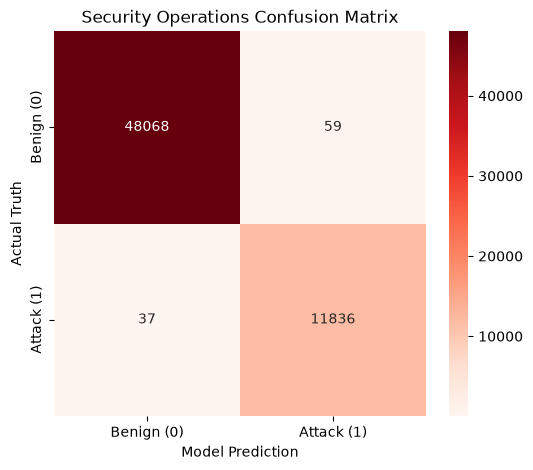

In [13]:
# Module 5: Evaluation in Realistic Security Settings
# ==========================================


from sklearn.metrics import confusion_matrix


# Using our best model's predictions (Random Forest from Module 4.4)
# Making it binary (0 = normal, 1 = any Attack) simulating the descision of should I activate alarm or not

y_test_binary = (y_test_sub > 0).astype(int) # an xrisimopoihsoume ola ta data tote -> y_test_shuff. Alliws me to deigma ton 60k -> y_test_sub
y_pred_binary = (preds_rf > 0).astype(int)

cm_bin = confusion_matrix(y_test_binary, y_pred_binary) # calculating confusion matrix
TN, FP, FN, TP = cm_bin.ravel()

# Assuming  Test Set (20% of data of 5 days) is equal with aprx 1 day of network traffic
print("--- SOC Daily Alert Report (Simulated 24h Traffic with 20 percent of data) ---")
print(f"Total Network Flows Analyzed: {len(y_test_sub):,}")
print(f"True Attacks Blocked (True Positives): {TP:,}")
print(f"Attacks Missed (False Negatives): {FN:,}  <-- CRITICAL INCIDENTS (Security Cost)")
print(f"False Alarms (False Positives): {FP:,}  <-- ANALYST FATIGUE (Operational Cost)")

#  Security Usefulness
alert_volume = TP + FP
fp_rate_alerts = (FP / alert_volume) * 100 if alert_volume > 0 else 0

print(f"\nTotal Alerts Generated for SOC: {alert_volume:,}")
print(f"Percentage of Alerts that are False (Wasted Time): {fp_rate_alerts:.2f}%")

# Visualisation
plt.figure(figsize=(6, 5))
sns.heatmap(cm_bin, annot=True, fmt="d", cmap="Reds", xticklabels=['Benign (0)', 'Attack (1)'], yticklabels=['Benign (0)', 'Attack (1)'])
plt.ylabel('Actual Truth')
plt.xlabel('Model Prediction')
plt.title('Security Operations Confusion Matrix')
plt.show()

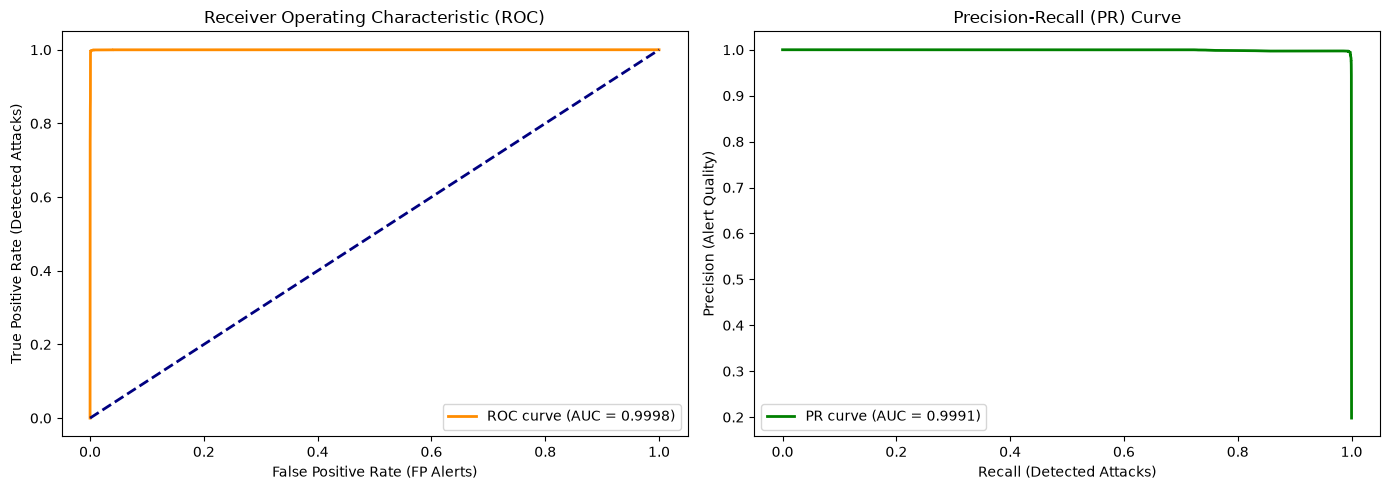

In [14]:


from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score

#y_pred_probs = rf_model.predict_proba(X_test_sub)[:, 1] # Pi8anotites epi8esis, KSana an uelame olo to set tha eixame X_test_shuf

y_pred_probs = 1.0 - rf_model.predict_proba(X_test_sub)[:, 0] # Pi8anotites epi8esis, KSana an uelame olo to set tha eixame X_test_shuf
# Η h na EINAI epi8esi, einai to 100% - p(Benign)   //   (klasi 0)

fpr, tpr, thresholds_roc = roc_curve(y_test_binary, y_pred_probs)
roc_auc = auc(fpr, tpr)

precision, recall, thresholds_pr = precision_recall_curve(y_test_binary, y_pred_probs)
pr_auc = average_precision_score(y_test_binary, y_pred_probs)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot ROC
ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax1.set_xlabel('False Positive Rate (FP Alerts)')
ax1.set_ylabel('True Positive Rate (Detected Attacks)')
ax1.set_title('Receiver Operating Characteristic (ROC)')
ax1.legend(loc="lower right")

# Plot PR
ax2.plot(recall, precision, color='green', lw=2, label=f'PR curve (AUC = {pr_auc:.4f})')
ax2.set_xlabel('Recall (Detected Attacks)')
ax2.set_ylabel('Precision (Alert Quality)')
ax2.set_title('Precision-Recall (PR) Curve')
ax2.legend(loc="lower left")

plt.tight_layout()
plt.show()

/tmp/ipykernel_3872/3022858875.py:29: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_attack, X_shap, show=False)


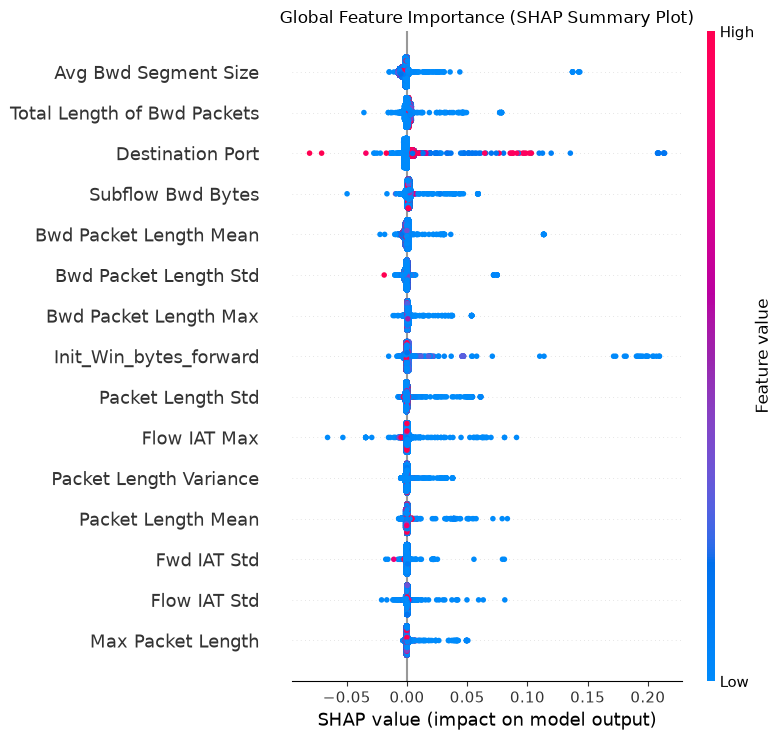


--- Local Explanations (Analyst Triage Simulation) ---
Investigating True Positive Attack...



Investigating False Positive Alarm...


In [19]:
# Module 5.2: Explainability, Trust and Model Debugging
# ==========================================

import shap


shap.initjs()

# Sample 50k to prevent memory/cpu overflow during shap computation
X_shap = X_test_shuf.sample(n=50000, random_state=42)

# Init explainer and compute shap values
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_shap, check_additivity=False)

# Extract attack class values (index 1)
shap_attack = shap_values[1] if isinstance(shap_values, list) else shap_values
expected_val = explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value

# Global explanation plot
plt.figure(figsize=(10, 6))
# Εξαγωγή των SHAP values με ασφάλεια (υποστηρίζει και παλιές και νέες εκδόσεις του SHAP)
if isinstance(shap_values, list):
    shap_attack = shap_values[1]
elif len(shap_values.shape) == 3:
    shap_attack = shap_values[:, :, 1]
else:
    shap_attack = shap_values
shap.summary_plot(shap_attack, X_shap, show=False)
#shap.summary_plot(shap_attack[1], X_shap, show=False)
plt.title('Global Feature Importance (SHAP Summary Plot)')
plt.tight_layout()
plt.show()

# Local explanations (triage debugging)

y_actual = (y_test_sub > 0).astype(int) # change to y_test_shuf for complete dataset testing
y_pred = (preds_rf > 0).astype(int)

tp_indices = y_actual[(y_actual == 1) & (y_pred == 1)].index
fp_indices = y_actual[(y_actual == 0) & (y_pred == 1)].index

print("\n--- Local Explanations (Analyst Triage Simulation) ---")

X_tp = X_test_sub.loc[[tp_indices[0]]]     # change to X_test_shuf for complete dataset testing
X_fp = X_test_sub.loc[[fp_indices[0]]]     # change to X_test_shuf for complete dataset testing

shap_tp = explainer.shap_values(X_tp, check_additivity=False)
shap_fp = explainer.shap_values(X_fp, check_additivity=False)

# 1D array with Size == Features
def extract_1d_shap(sv):
    if isinstance(sv, list):
        return sv[1][0]          # List of arrays (for old SHAP)
    elif len(sv.shape) == 3:
        return sv[0, :, 1]       # 3D array (New SHAP: Samples, Features, Classes)
    else:
        return sv[0]             # 2D array (Single Class)

sv_tp_1d = extract_1d_shap(shap_tp)
sv_fp_1d = extract_1d_shap(shap_fp)

# Extracting features as 1D numpy arrays
ft_tp_1d = X_tp.iloc[0].values
ft_fp_1d = X_fp.iloc[0].values

exp_val = explainer.expected_value
if isinstance(exp_val, (list, tuple, np.ndarray)):
    expected_value_float = float(exp_val[1]) if len(exp_val) > 1 else float(exp_val[0])
else:
    expected_value_float = float(exp_val)

feature_names_list = X_test_shuf.columns.tolist()

print("Investigating True Positive Attack...")
display(shap.force_plot(
    expected_value_float, 
    sv_tp_1d, 
    ft_tp_1d,      
    feature_names=feature_names_list
))

print("\nInvestigating False Positive Alarm...")
display(shap.force_plot(
    expected_value_float, 
    sv_fp_1d, 
    ft_fp_1d, 
    feature_names=feature_names_list
))

In [16]:
# Module 5.3: Adversarial ML (Evasion Attack Simulation)
# ==========================================


# Finding true positives
y_actual = (y_test_sub > 0).astype(int) # change to y_test_shuf for complete dataset testing
y_pred = (preds_rf > 0).astype(int)
tp_mask = (y_actual == 1) & (y_pred == 1)

X_attacks_detected = X_test_sub[tp_mask].copy() # change to x_test_shuf for complete dataset testing
total_targets = len(X_attacks_detected)
print(f"Original Detected Attacks (Baseline): {total_targets:,}")

# we simulate noise to bypass the IDS
np.random.seed(42)
noise_factor = 0.5  # influences how much the attacker is tampering with the package

# adding gaussian noise
noise = np.random.normal(0, noise_factor, X_attacks_detected.shape)
X_evasion = X_attacks_detected + noise

# Testing the models robustness against evaded traffic
print("Testing model robustness against perturbed traffic...")
preds_evasion = rf_model.predict(X_evasion)
evasion_binary = (preds_evasion > 0).astype(int)

# Measure Degradation
# any 0 benign attack is a bypass of the hacker since we know everyone of these are actual attacks
attacks_bypassed = total_targets - sum(evasion_binary)
degradation_rate = (attacks_bypassed / total_targets) * 100

print("\n--- Evasion Attack Results ---")
print(f"Attacks that bypassed the model (False Negatives): {attacks_bypassed:,} out of {total_targets:,}")
print(f"Detection Degradation Rate (Fragility): {degradation_rate:.2f}%")

Original Detected Attacks (Baseline): 11,836
Testing model robustness against perturbed traffic...

--- Evasion Attack Results ---
Attacks that bypassed the model (False Negatives): 9,372 out of 11,836
Detection Degradation Rate (Fragility): 79.18%
